# ch250 — Variance

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. Spread Around the Mean

Expected value *(ch249)* tells you where the distribution is centered. It tells you nothing about how spread out it is. Two distributions can have the same mean but radically different spread.

**Variance** measures the expected squared deviation from the mean:
$$\text{Var}(X) = E\left[(X - \mu)^2\right]$$

where μ = E[X].

**Standard deviation**: σ = √Var(X). Same units as X, which makes it interpretable.

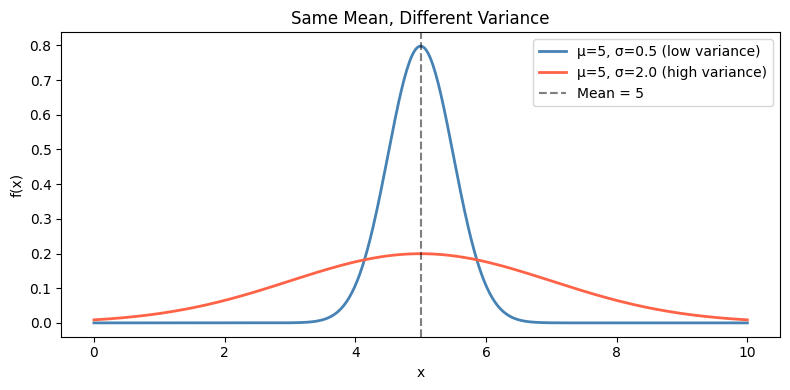

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Two distributions with same mean but different variance
mu = 5

x = np.linspace(0, 10, 500)
rv_narrow = stats.norm(loc=mu, scale=0.5)
rv_wide   = stats.norm(loc=mu, scale=2.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, rv_narrow.pdf(x), 'steelblue', linewidth=2, label='μ=5, σ=0.5 (low variance)')
ax.plot(x, rv_wide.pdf(x),   'tomato',    linewidth=2, label='μ=5, σ=2.0 (high variance)')
ax.axvline(mu, color='black', linestyle='--', alpha=0.5, label='Mean = 5')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Same Mean, Different Variance')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Computing Variance

The computational formula avoids subtracting the mean explicitly:
$$\text{Var}(X) = E[X^2] - E[X]^2$$

*Proof*:
$$E[(X-\mu)^2] = E[X^2 - 2\mu X + \mu^2] = E[X^2] - 2\mu E[X] + \mu^2 = E[X^2] - \mu^2$$

In [2]:
def variance_discrete(values, probs):
    values, probs = np.array(values, float), np.array(probs, float)
    mu = np.sum(values * probs)
    # Definition: E[(X-mu)^2]
    var_def = np.sum((values - mu)**2 * probs)
    # Computational: E[X^2] - mu^2
    var_comp = np.sum(values**2 * probs) - mu**2
    return mu, var_def, var_comp

faces = np.arange(1, 7)
pmf = np.full(6, 1/6)

mu, var_def, var_comp = variance_discrete(faces, pmf)
print(f"Fair die:")
print(f"  μ = E[X] = {mu:.4f}")
print(f"  Var(X) via definition = {var_def:.6f}")
print(f"  Var(X) via E[X²]-μ²  = {var_comp:.6f}")
print(f"  σ = √Var(X) = {np.sqrt(var_def):.4f}")
print(f"  numpy agrees: {np.isclose(var_def, np.var([1,2,3,4,5,6]))}")  # ddof=0 (population)

Fair die:
  μ = E[X] = 3.5000
  Var(X) via definition = 2.916667
  Var(X) via E[X²]-μ²  = 2.916667
  σ = √Var(X) = 1.7078
  numpy agrees: True


## 3. Variance of Scaled and Shifted Variables

$$\text{Var}(aX + b) = a^2 \text{Var}(X)$$

Note: adding a constant b shifts the distribution but does not change its spread. Scaling by a multiplies the variance by a².

This is why standard deviation scales linearly with the variable (σ(aX) = |a|σ) while variance scales quadratically.

In [3]:
# Verify Var(aX + b) = a^2 * Var(X)
a, b = 3, 10

mu_X, var_X, _ = variance_discrete(faces, pmf)

# Y = aX + b
y_values = a * faces + b
mu_Y, var_Y, _ = variance_discrete(y_values, pmf)

print(f"X: μ={mu_X:.4f}, Var={var_X:.4f}")
print(f"Y = {a}X + {b}: μ={mu_Y:.4f}, Var={var_Y:.4f}")
print(f"Expected Var(Y) = a²·Var(X) = {a}²×{var_X:.4f} = {a**2 * var_X:.4f}")
print(f"Match: {np.isclose(var_Y, a**2 * var_X)}")

X: μ=3.5000, Var=2.9167
Y = 3X + 10: μ=20.5000, Var=26.2500
Expected Var(Y) = a²·Var(X) = 3²×2.9167 = 26.2500
Match: True


## 4. Variance of Sums (Independent RVs)

For **independent** random variables X and Y:
$$\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)$$

For **dependent** variables, you need the covariance:
$$\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y) + 2\text{Cov}(X, Y)$$

In [4]:
from itertools import product

# Var(die1 + die2) should equal Var(die1) + Var(die2)
Omega2 = list(product(faces, faces))
p2 = 1 / len(Omega2)

sums = np.array([d1 + d2 for d1, d2 in Omega2])
E_sum = sums.mean()
Var_sum = np.mean((sums - E_sum)**2)

print(f"Var(die1 + die2) = {Var_sum:.4f}")
print(f"Var(die1) + Var(die2) = {var_X + var_X:.4f}")
print(f"Match: {np.isclose(Var_sum, 2 * var_X)}")

# Standard deviation scales as sqrt(n) for n independent identically-distributed vars
print("\nσ scaling for n independent dice:")
sigma_one = np.sqrt(var_X)
for n in [1, 4, 9, 25, 100]:
    sigma_sum = np.sqrt(n) * sigma_one
    print(f"  n={n:3d}: σ(sum) = √{n}×{sigma_one:.4f} = {sigma_sum:.4f}")

Var(die1 + die2) = 5.8333
Var(die1) + Var(die2) = 5.8333
Match: True

σ scaling for n independent dice:
  n=  1: σ(sum) = √1×1.7078 = 1.7078
  n=  4: σ(sum) = √4×1.7078 = 3.4157
  n=  9: σ(sum) = √9×1.7078 = 5.1235
  n= 25: σ(sum) = √25×1.7078 = 8.5391
  n=100: σ(sum) = √100×1.7078 = 17.0783


## 5. Sample Variance vs Population Variance

From a sample of n observations, the **biased** estimator divides by n; the **unbiased** estimator divides by n−1 (Bessel's correction):

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

In [5]:
# Demonstrate why n-1 not n for sample variance
rng = np.random.default_rng(seed=42)
true_variance = var_X  # known for fair die

n_simulations = 10_000
sample_size = 10

biased_estimates = []
unbiased_estimates = []

for _ in range(n_simulations):
    sample = rng.choice(faces, size=sample_size, p=pmf)
    biased_estimates.append(np.var(sample, ddof=0))    # divide by n
    unbiased_estimates.append(np.var(sample, ddof=1))  # divide by n-1

print(f"True population variance: {true_variance:.4f}")
print(f"Average biased estimate (ddof=0):   {np.mean(biased_estimates):.4f}  <- underestimates")
print(f"Average unbiased estimate (ddof=1): {np.mean(unbiased_estimates):.4f}  <- matches")
print(f"\nUse ddof=1 when estimating variance from a sample.")
print(f"Use ddof=0 for the population (when you have all data).")

True population variance: 2.9167
Average biased estimate (ddof=0):   2.6197  <- underestimates
Average unbiased estimate (ddof=1): 2.9108  <- matches

Use ddof=1 when estimating variance from a sample.
Use ddof=0 for the population (when you have all data).


## 6. Summary

- Var(X) = E[(X−μ)²] = E[X²] − E[X]² measures spread around the mean.
- σ = √Var(X) is the standard deviation — same units as X.
- Var(aX+b) = a²·Var(X): constants shift the mean, not the spread; scaling multiplies variance by a².
- For independent RVs: Var(X+Y) = Var(X) + Var(Y). Dependent variables require covariance terms.
- Sample variance divides by n−1 (unbiased); population variance divides by n.

---

## 7. Forward References

Mean and variance are the first two moments of a distribution. They appear in the normal distribution (ch253) as its defining parameters. The Central Limit Theorem (ch254) states that sums of random variables with finite mean and variance converge to a normal distribution — this is why σ/√n appears in confidence intervals (Part IX, ch280). Covariance generalizes variance to pairs of variables and becomes the covariance matrix in Part VI linear algebra *(introduced in ch176)* and Part IX regression *(ch281)*.